# Federated Learning with Flower

We turn the LSTM into a federated model, where each WESAD subject becomes a separate Flower client and only model weights circulate through the network, raw data remains on the client.

The strategy used for aggregating: FedAvg, sample-weighted averaging of client weight updates. Useful for WESAD because the recorded subjects produced similar amounts of data and roughly the same set of classes.

In [1]:
import sys, pathlib, importlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

# Force-reload so the kernel picks up any config/code changes without a restart
import src.config, src.model, src.fl.data_partition, src.fl.simulation
for _mod in [src.config, src.model, src.fl.data_partition, src.fl.simulation]:
    importlib.reload(_mod)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import LABEL_NAMES, MODELS_DIR
from src.fl.data_partition import partition_by_subject, summarize_partitions
from src.fl.simulation import FLRunConfig, run

sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

## Inspect the per-client partitions
Each subject = one client. The scaler is fit per-client on each client's own training data.

In [2]:
partitions = partition_by_subject()
summary = summarize_partitions(partitions)
summary


,n_train,n_test,normal,stress
subject,,,,
S10,96,25,76,45
S11,93,24,75,42
S13,93,24,75,42
S14,93,24,75,42
S15,94,24,76,42
S16,92,24,75,41
S17,96,25,76,45
S2,88,22,73,37
S3,88,23,72,39


Text(0.5, 1.0, 'Per-client class distribution (proportions)')

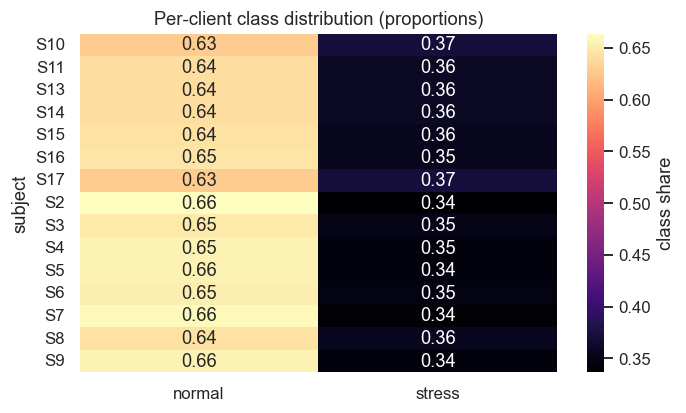

In [3]:
class_cols = [c for c in summary.columns if c not in ('n_train', 'n_test')]
props = summary[class_cols].div(summary[class_cols].sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(props, annot=True, fmt='.2f', cmap='magma', cbar_kws={'label': 'class share'}, ax=ax)
ax.set_title('Per-client class distribution (proportions)')

## Run a small simulation (warm-started from the previous previously generated model)
We use a 4-subject subset for a fast test.

In [4]:
cfg = FLRunConfig(
    rounds=3,
    local_epochs=2,
    batch_size=32,
    subjects=['S2', 'S3', 'S4', 'S5'],
    output=MODELS_DIR / 'fl_global_smoke.keras',
)
history, final_weights = run(cfg)

Client partitions:
         n_train  n_test  normal  stress
subject                                 
S2            88      22      73      37
S3            88      23      72      39
S4            90      23      74      39
S5            92      24      76      40
Warm-starting from C:\Users\daniion6\AndroidStudioProjects\MindWave\ml\models\mindwave_stress.keras

   Starting Flower simulation: 4 clients × 3 rounds × 2 local epochs 



c:\Users\daniion6\AndroidStudioProjects\MindWave\.venv-312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-06-10 02:32:49,603	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.

            This is a deprecated feature. It will be removed
            entirely in future versions of Flower.
        
INFO :      Starting Flower ServerApp, config: num_rounds=3, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 4 clients (out of 4)
c:\Users\daniion6\AndroidStudioProject


Final global model saved at C:\Users\daniion6\AndroidStudioProjects\MindWave\ml\models\fl_global_smoke.keras

=== Aggregated metrics per round ===
  losses_distributed:
    round 1: loss=0.2977
    round 2: loss=0.2512
    round 3: loss=0.2156
  fit metrics (weighted avg over clients):
    round 1 loss=0.1546
    round 2 loss=0.0925
    round 3 loss=0.0469
    round 1 accuracy=0.9832
    round 2 accuracy=0.9888
    round 3 accuracy=0.9916
  evaluate metrics (weighted avg over clients):
    round 1 accuracy=0.9783
    round 2 accuracy=0.9783
    round 3 accuracy=0.9783
History → C:\Users\daniion6\AndroidStudioProjects\MindWave\ml\models\fl_global_smoke.history.json


c:\Users\daniion6\AndroidStudioProjects\MindWave\.venv-312\Lib\site-packages\keras\src\backend\tensorflow\core.py:171: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  return np.array(x)


## Round-by-round aggregated metrics

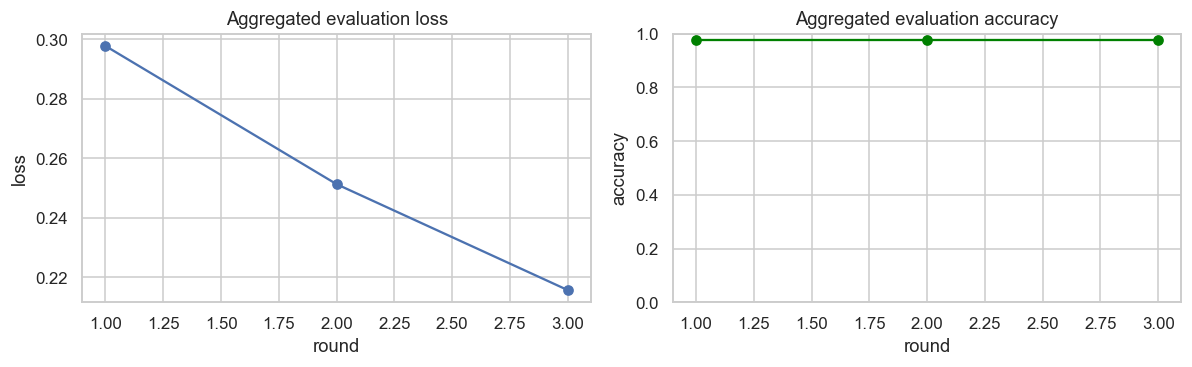

In [5]:
def history_to_df(pairs):
    return pd.DataFrame(pairs, columns=['round', 'value']).set_index('round')

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

loss_df = history_to_df(history.losses_distributed)
loss_df.plot(ax=axes[0], marker='o', legend=False)
axes[0].set_title('Aggregated evaluation loss'); axes[0].set_ylabel('loss')

if 'accuracy' in history.metrics_distributed:
    acc_df = history_to_df(history.metrics_distributed['accuracy'])
    acc_df.plot(ax=axes[1], marker='o', color='green', legend=False)
    axes[1].set_title('Aggregated evaluation accuracy'); axes[1].set_ylabel('accuracy')
    axes[1].set_ylim(0, 1)
fig.tight_layout()

Text(0.5, 0, 'round')

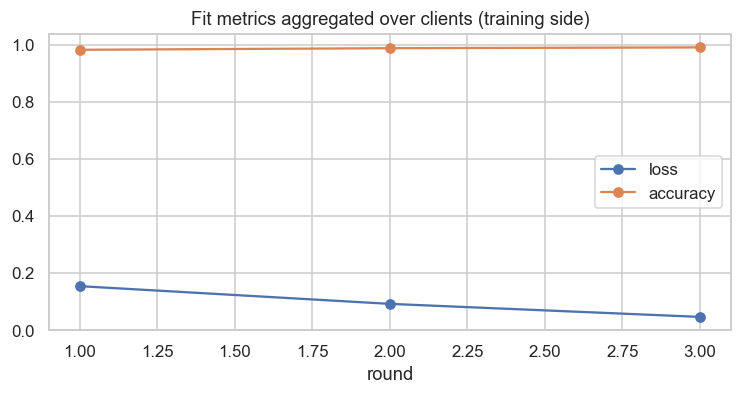

In [6]:
fig, ax = plt.subplots(figsize=(8, 3.5))
for k, series in history.metrics_distributed_fit.items():
    history_to_df(series).rename(columns={'value': k}).plot(ax=ax, marker='o')
ax.set_title('Fit metrics aggregated over clients (training side)')
ax.set_xlabel('round')

## Per-client final evaluation accuracy
We re-evaluate the final aggregated weights locally on each client's own held-out 20 % to see how the global model behaves on every user.

,loss,accuracy,n_test
subject,,,
S2,0.014,1.000,22
S3,0.013,1.000,23
S4,0.012,1.000,23
S5,0.790,0.917,24


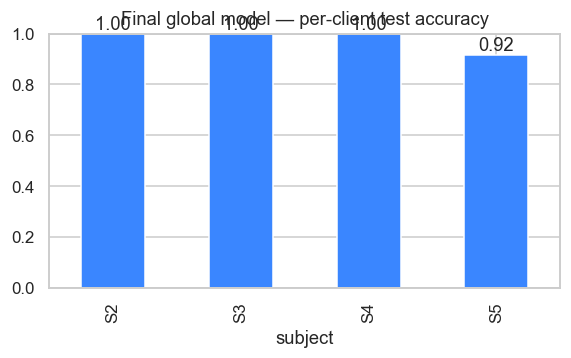

In [7]:
import tensorflow as tf
from src.model import build_lstm

# Derive n_classes from the actual partition labels, not from LABEL_NAMES
# (avoids stale-kernel issues when the config changes)
n_classes = int(max(p.y_train.max() for p in partitions.values()) + 1)

global_model = build_lstm(
    input_shape=next(iter(partitions.values())).X_train.shape[1:],
    n_classes=n_classes,
)
global_model.set_weights(final_weights)

rows = []
for sid in cfg.subjects:
    p = partitions[sid]
    loss, acc = global_model.evaluate(p.X_test, p.y_test, verbose=0)
    rows.append({'subject': sid, 'loss': loss, 'accuracy': acc, 'n_test': p.n_test})
per_client = pd.DataFrame(rows).set_index('subject')
display(per_client.round(3))

fig, ax = plt.subplots(figsize=(6, 3))
per_client['accuracy'].plot(kind='bar', color='#3a86ff', ax=ax)
ax.set_ylim(0, 1); ax.set_title('Final global model — per-client test accuracy')
for c in ax.containers: ax.bar_label(c, fmt='%.2f')
    

Throughout the entire run, no raw signal ever crosses the network, only the models weights and scalar metrics